In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# 加载数据
df = pd.read_csv("D:\smart_home_energy_usage_dataset.csv", parse_dates=['timestamp'])
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
import matplotlib.pyplot as plt
import matplotlib

# 设置支持中文的字体（Windows 通常用 SimHei，macOS 用 Arial Unicode MS）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS
# plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']  # Linux（需安装）

# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False


# 查看数据概览
print(df.info())
print(df.describe())
print(df['season'].value_counts())
print(df['appliance'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1000000 non-null  datetime64[ns]
 1   home_id                 1000000 non-null  int64         
 2   energy_consumption_kWh  1000000 non-null  float64       
 3   temperature_setting_C   1000000 non-null  float64       
 4   occupancy_status        1000000 non-null  object        
 5   appliance               1000000 non-null  object        
 6   usage_duration_minutes  1000000 non-null  int64         
 7   season                  1000000 non-null  object        
 8   day_of_week             1000000 non-null  object        
 9   holiday                 1000000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 76.3+ MB
None
              home_id  energy_consumption_kWh  temperatur

In [3]:
# 处理缺失值
df.dropna(subset=['energy_consumption_kWh', 'temperature_setting_C'], inplace=True)

# 统一占用状态格式
df['occupancy_status'] = df['occupancy_status'].astype(str).str.lower().map({'occupied': 1, 'unoccupied': 0})


# 其他列用均值填充（如能耗数据）
numeric_cols = ["energy_consumption_kWh", "usage_duration_minutes"]
for col in numeric_cols:
  df[col] = df[col].fillna(df[col].mean())

# 2. 处理异常值
# 假设温度应在 10°C ~ 40°C 之间，否则替换为中位数
temp_median = df["temperature_setting_C"].median()
df["temperature_setting_C"] = np.where(
    (df["temperature_setting_C"] < 10) |
    (df["temperature_setting_C"] > 40),
    temp_median,
    df["temperature_setting_C"]
)

# 提取时间特征
df['hour'] = df['timestamp'].dt.hour
df['day_of_month'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
# 季节编码（如果季节是文本）
season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
df['season_code'] = df['season'].map(season_map)

# 星期编码
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
            'Friday': 4, 'Saturday': 5, 'Sunday': 6}
df['day_code'] = df['day_of_week'].map(day_map)
# 4. 添加计算字段（如能耗效率）
df["energy_per_hour"] = df["energy_consumption_kWh"] / df["usage_duration_minutes"] *60

# 5. 删除完全无效的行（如全为NaN的行）
cleaned_data = df.dropna(how="all")

# --------------------------
# 保存清洗后的数据
# --------------------------
output_path = "D:\smart_home_cleaned.csv"
cleaned_data.to_csv(output_path, index=False, encoding="utf-8")

print(f"数据清洗完成，已保存至: {output_path}")
print("清洗后数据预览:")
print(cleaned_data.head())

数据清洗完成，已保存至: D:\smart_home_cleaned.csv
清洗后数据预览:
            timestamp  home_id  energy_consumption_kWh  temperature_setting_C  \
0 2023-01-01 00:00:00       44                    2.87                   22.1   
1 2023-01-01 01:00:00       81                    0.56                   15.4   
2 2023-01-01 02:00:00       94                    4.49                   22.4   
3 2023-01-01 03:00:00       20                    2.13                   24.6   
4 2023-01-01 04:00:00        3                    2.74                   21.4   

   occupancy_status     appliance  usage_duration_minutes  season day_of_week  \
0                 1  Refrigerator                     111  Spring      Sunday   
1                 1          HVAC                     103  Summer      Sunday   
2                 1   Electronics                      12  Autumn      Sunday   
3                 0    Dishwasher                      54  Autumn      Sunday   
4                 0          HVAC                       6  S

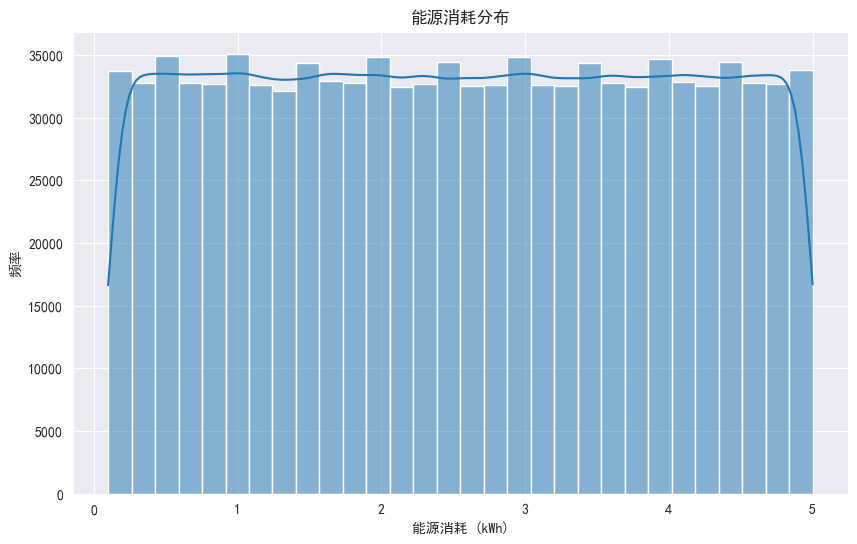

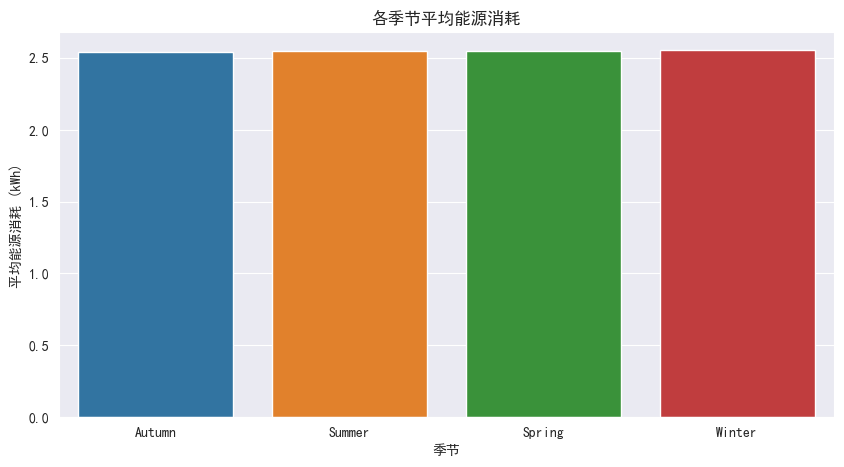

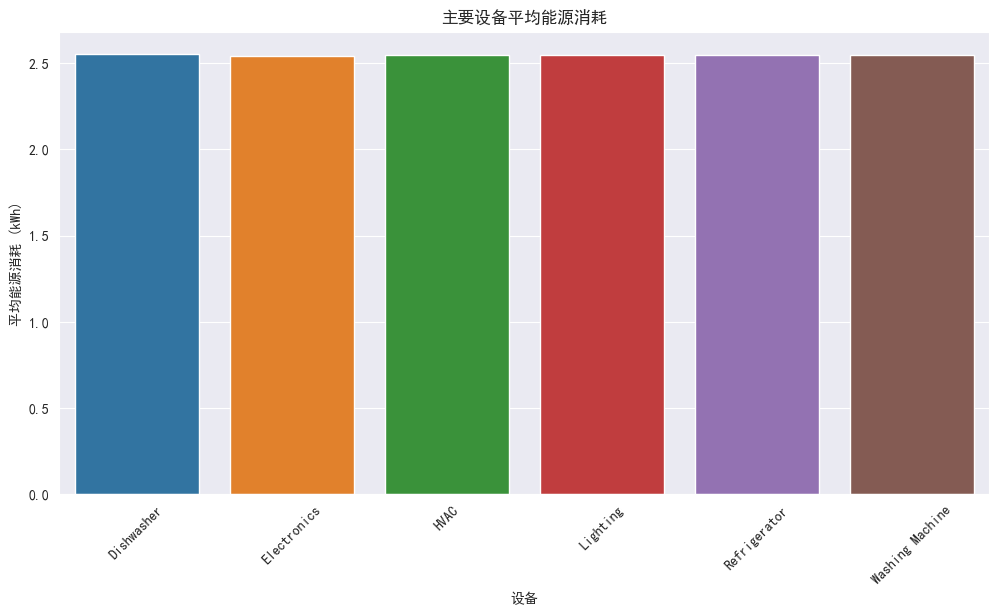


占用状态与能源消耗:
                      mean   count
occupancy_status                  
0                 2.547851  499606
1                 2.549825  500394


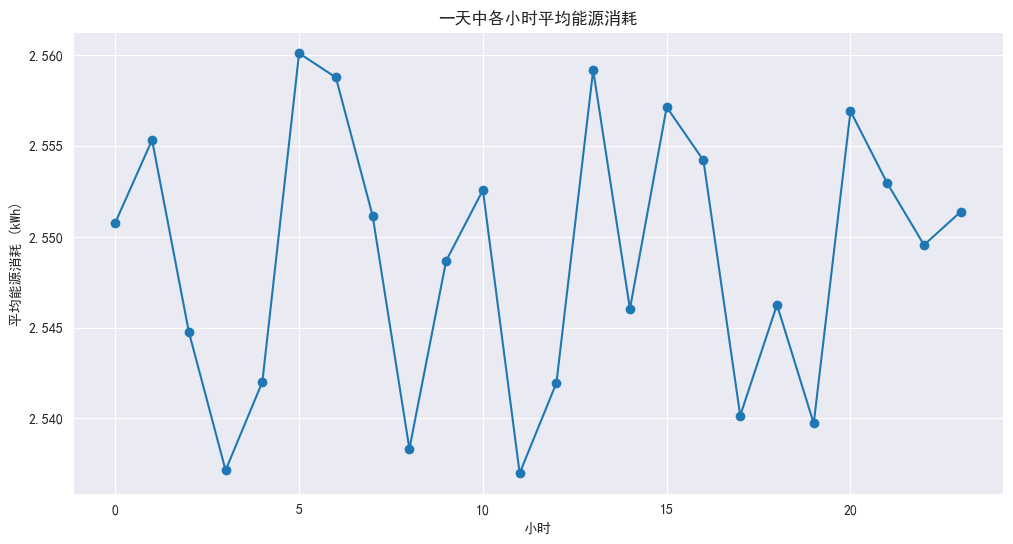

In [4]:
# 能源消耗分布
plt.figure(figsize=(10, 6))
sns.histplot(df['energy_consumption_kWh'], bins=30, kde=True)
plt.title('能源消耗分布')
plt.xlabel('能源消耗 (kWh)')
plt.ylabel('频率')
plt.show()

# 按季节分析能源消耗
seasonal_energy = df.groupby('season')['energy_consumption_kWh'].mean().sort_values()
plt.figure(figsize=(10, 5))
sns.barplot(x=seasonal_energy.index, y=seasonal_energy.values)
plt.title('各季节平均能源消耗')
plt.xlabel('季节')
plt.ylabel('平均能源消耗 (kWh)')
plt.show()

# 设备使用与能源消耗关系
top_appliances = df['appliance'].value_counts().head(10).index
appliance_energy = df[df['appliance'].isin(top_appliances)].groupby('appliance')['energy_consumption_kWh'].mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=appliance_energy.index, y=appliance_energy.values)
plt.title('主要设备平均能源消耗')
plt.xlabel('设备')
plt.ylabel('平均能源消耗 (kWh)')
plt.xticks(rotation=45)
plt.show()

# 占用状态与能源消耗
occupancy_energy = df.groupby('occupancy_status')['energy_consumption_kWh'].agg(['mean', 'count'])
print("\n占用状态与能源消耗:")
print(occupancy_energy)

# 时间模式分析 - 按小时
hourly_energy = df.groupby('hour')['energy_consumption_kWh'].mean()
plt.figure(figsize=(12, 6))
plt.plot(hourly_energy.index, hourly_energy.values, marker='o')
plt.title('一天中各小时平均能源消耗')
plt.xlabel('小时')
plt.ylabel('平均能源消耗 (kWh)')
plt.grid(True)
plt.show()

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 准备建模数据
features = ['hour', 'day_code', 'season_code', 'holiday', 'temperature_setting_C', 'usage_duration_minutes']
target = 'energy_consumption_kWh'

X = df[features]
y = df[target]

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # 也可以用 'median' 或 'constant'
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
print("X_train shape:", X_train.shape)
print("X_train dtype:", X_train.dtype)
import numpy as np

print("NaN in X_train:", np.isnan(X_train).any())
print("inf in X_train:", np.isinf(X_train).any())

print("NaN in X_test:", np.isnan(X_test).any())
print("inf in X_test:", np.isinf(X_test).any())
print("Columns with zero variance:", np.where(np.var(X_train, axis=0) == 0)[0])
print("X_train dtype:", X_train.dtype)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (800000, 6)
X_train dtype: float64
NaN in X_train: False
inf in X_train: False
NaN in X_test: False
inf in X_test: False
Columns with zero variance: []
X_train dtype: float64
X_train shape: (800000, 6)
X_test shape: (200000, 6)


In [7]:
# 随机森林模型
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 预测与评估
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n模型评估:")
print(f"平均绝对误差 (MAE): {mae:.2f} kWh")
print(f"R平方值 (R²): {r2:.2f}")
print("features 长度:", len(features))
print("feature_importances_ 长度:", len(rf_model.feature_importances_))



模型评估:
平均绝对误差 (MAE): 1.28 kWh
R平方值 (R²): -0.13
features 长度: 6
feature_importances_ 长度: 6


00:00:28 - cmdstanpy - INFO - Chain [1] start processing
00:01:01 - cmdstanpy - INFO - Chain [1] done processing


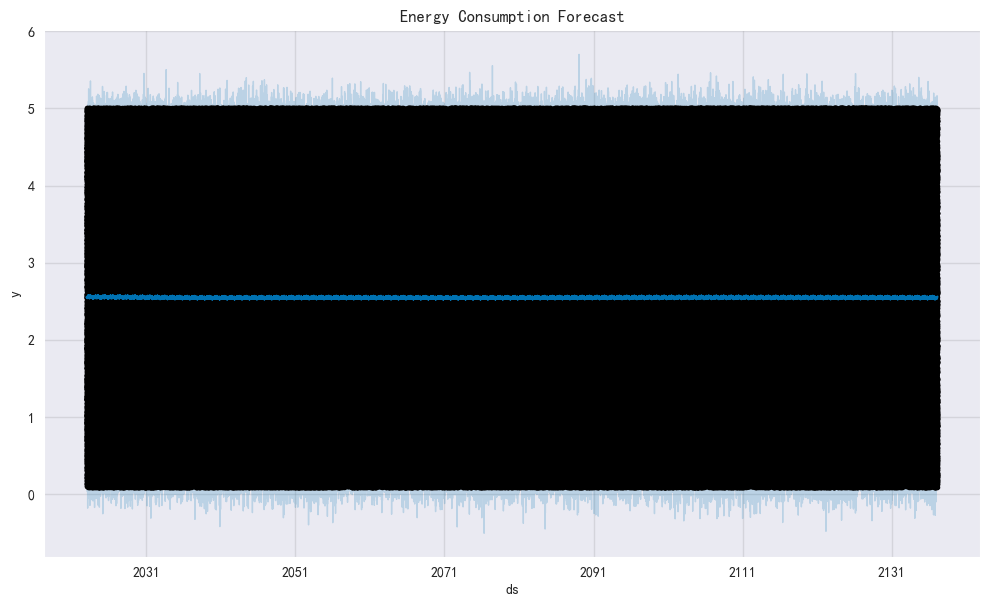

In [12]:
from prophet import Prophet

# 按日聚合能源消耗
daily_energy = df.groupby('timestamp')['energy_consumption_kWh'].sum().reset_index()
daily_energy.columns = ['ds', 'y']



from prophet import Prophet

# 1. 初始化模型时减少不确定性采样
model = Prophet(
    uncertainty_samples=100,  # 加速预测
    yearly_seasonality=True,  # 根据需求调整季节性
    weekly_seasonality=False  # 根据数据频率调整
)

# 2. 拟合模型
model.fit(daily_energy)  # df 是包含 'ds'（日期）和 'y'（值）列的数据框

# 3. 生成未来数据并预测
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)  # 快速预测

# 4. 可视化结果（可选）
fig = model.plot(forecast)
plt.title('Energy Consumption Forecast')
plt.show()

In [8]:
print("X_train.shape:", X_train.shape)
if isinstance(X_train, pd.DataFrame):
    features = X_train.columns.tolist()# 查看训练时的特征数量
    # 确保长度一致
assert len(features) == len(rf_model.feature_importances_),"features 和 feature_importances_ 长度仍然不一致！"

X_train.shape: (800000, 6)


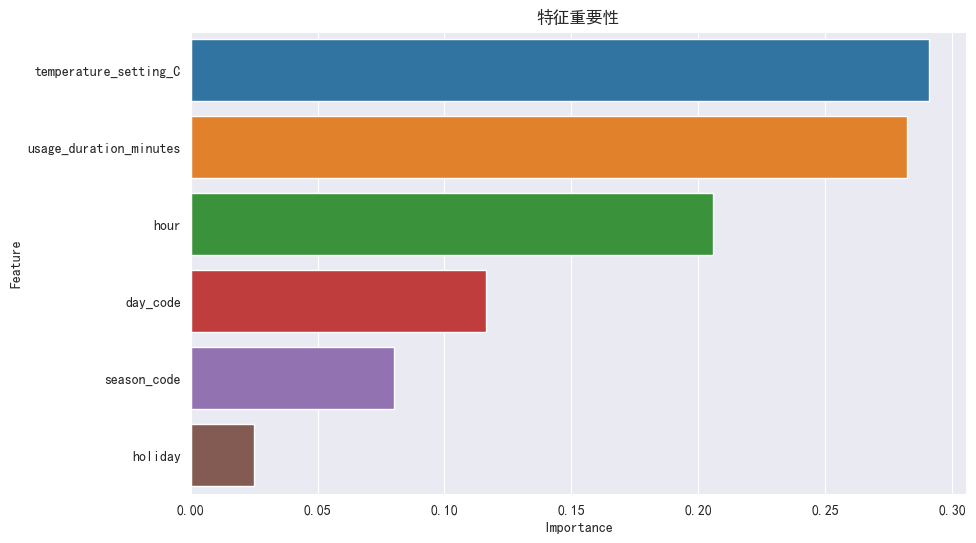

In [9]:
# 特征重要性
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('特征重要性')
plt.show()

In [10]:
# 生成洞察报告
insights = {
    "高峰能耗时段": f"{df['hour'].mode()[0]}点",
    "最高能耗季节": df.groupby('season')['energy_consumption_kWh'].mean().idxmax(),
    "最耗能设备": df.groupby('appliance')['energy_consumption_kWh'].mean().idxmax(),
    "占用状态影响": "有人在家时能耗比无人时高{:.1f}%".format(
        (df[df['occupancy_status']==1]['energy_consumption_kWh'].mean() /
         df[df['occupancy_status']==0]['energy_consumption_kWh'].mean() - 1) * 100),
    "模型预测准确性": f"模型可解释{r2*100:.1f}%的能耗变化"
}

print("\n关键业务洞察:")
for key, value in insights.items():
    print(f"- {key}: {value}")


关键业务洞察:
- 高峰能耗时段: 0点
- 最高能耗季节: Winter
- 最耗能设备: Dishwasher
- 占用状态影响: 有人在家时能耗比无人时高0.1%
- 模型预测准确性: 模型可解释-13.2%的能耗变化


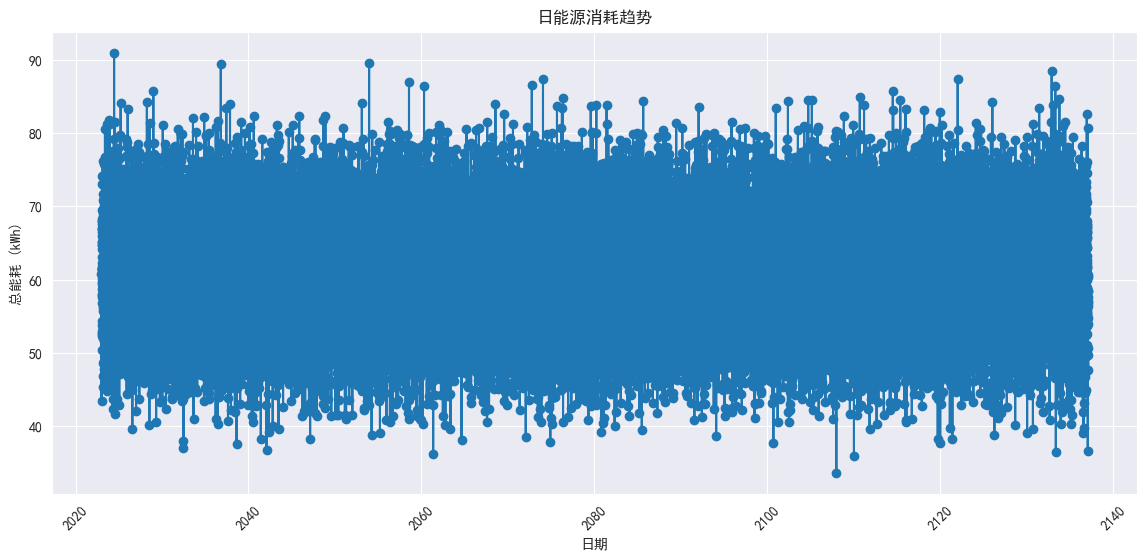

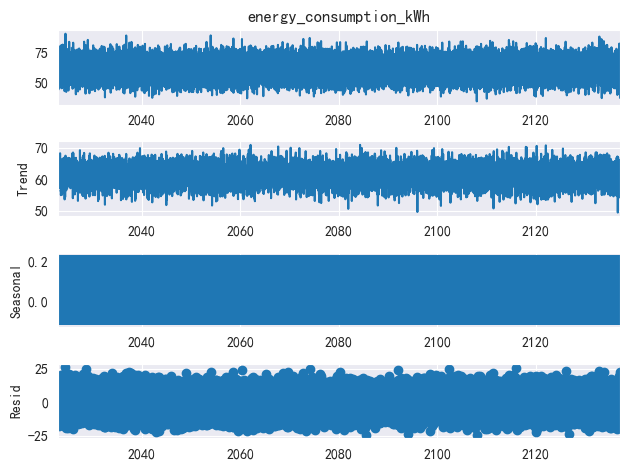

In [24]:
# 创建时间序列视图（按日）
df['date'] = df['timestamp'].dt.date
daily_energy = df.groupby('date')['energy_consumption_kWh'].sum().reset_index()

# 可视化日能耗趋势
plt.figure(figsize=(14, 6))
plt.plot(daily_energy['date'], daily_energy['energy_consumption_kWh'], marker='o')
plt.title('日能源消耗趋势')
plt.xlabel('日期')
plt.ylabel('总能耗 (kWh)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 季节性分解（需要statsmodels）
from statsmodels.tsa.seasonal import seasonal_decompose

# 确保数据是等间隔的（这里简化处理）
if len(daily_energy) > 60:  # 确保有足够数据
    decomposition = seasonal_decompose(daily_energy.set_index('date')['energy_consumption_kWh'],
                                      model='additive', period=7)
    decomposition.plot()
    plt.show()